In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, random, gc
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = '/content/drive/MyDrive/MRI_Brain_Tumor_Project'
CLAHE_DIR    = f'{PROJECT_ROOT}/data/clahe_processed'
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
CLASS_NAMES  = ['glioma', 'meningioma', 'notumor', 'pituitary']

test_ds_check = tf.keras.utils.image_dataset_from_directory(
    f'{CLAHE_DIR}/Testing',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', class_names=CLASS_NAMES, shuffle=False
).map(
    lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

effnet_model = tf.keras.models.load_model(
    f'{PROJECT_ROOT}/models/checkpoints/effnet_correct_s2b.keras'
)

PRED_DIR        = f'{PROJECT_ROOT}/results/predictions'
y_true          = np.load(f'{PRED_DIR}/y_true.npy')
y_pred_baseline = np.load(f'{PRED_DIR}/y_pred_baseline.npy')
y_pred_effnet   = np.load(f'{PRED_DIR}/y_pred_effnet_final.npy')

print("Extracting test images...")
X_list, y_list = [], []
for x_batch, y_batch in test_ds_check:
    X_list.append(x_batch.numpy())
    y_list.append(y_batch.numpy())
X_test  = np.concatenate(X_list, axis=0).astype(np.float32)
y_check = np.concatenate(y_list, axis=0)
del X_list, y_list
gc.collect()

print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"X_test: {X_test.shape}")
print(f"Labels match y_true: {np.array_equal(y_check, y_true)}")
print(f"Baseline acc:     {np.mean(y_pred_baseline == y_true):.4f}")
print(f"EfficientNet acc: {np.mean(y_pred_effnet == y_true):.4f}")
print("\nReady.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1600 files belonging to 4 classes.
Extracting test images...
GPU: []
X_test: (1600, 224, 224, 3)
Labels match y_true: True
Baseline acc:     0.8894
EfficientNet acc: 0.9144

Ready.


In [ ]:
# McNemar's Test (Baseline vs EfficientNetB3)

from scipy.stats import chi2
import numpy as np
import json

# McNemar's test compares two classifiers on the same test set
# Contingency table:
#   b = baseline wrong, effnet right  → effnet uniquely correct
#   c = baseline right, effnet wrong  → baseline uniquely correct

baseline_correct = (y_pred_baseline == y_true)
effnet_correct   = (y_pred_effnet   == y_true)

# Four cells of the contingency table
both_correct     = np.sum( baseline_correct &  effnet_correct)
baseline_only    = np.sum( baseline_correct & ~effnet_correct)
effnet_only      = np.sum(~baseline_correct &  effnet_correct)
both_wrong       = np.sum(~baseline_correct & ~effnet_correct)

b = effnet_only    # effnet right, baseline wrong
c = baseline_only  # baseline right, effnet wrong


print("McNemar Contingency Table")

print(f"  Both correct:        {both_correct}")
print(f"  EfficientNet only:   {b}  ← effnet uniquely correct")
print(f"  Baseline only:       {c}  ← baseline uniquely correct")
print(f"  Both wrong:          {both_wrong}")
print(f"  Total test samples:  {len(y_true)}")

# McNemar statistic with continuity correction (standard for medical stats)
mcnemar_stat = (abs(b - c) - 1) ** 2 / (b + c)
p_value = 1 - chi2.cdf(mcnemar_stat, df=1)


print("McNemar's Test Result")

print(f"  b (EfficientNet uniquely correct): {b}")
print(f"  c (Baseline uniquely correct):     {c}")
print(f"  Chi-square statistic: {mcnemar_stat:.4f}")
print(f"  p-value:              {p_value:.6f}")
print(f"  Significance level:   α = 0.05")

if p_value < 0.05:
    print(f"\n  RESULT: p={p_value:.6f} < 0.05")
    print("  ✓ EfficientNetB3 is STATISTICALLY SIGNIFICANTLY better")
    print("    than the scratch CNN baseline.")
else:
    print(f"\n  RESULT: p={p_value:.6f} ≥ 0.05")
    print("  The difference is not statistically significant at α=0.05.")

print("Accuracy Summary")

print(f"  Scratch CNN baseline: {np.mean(baseline_correct)*100:.2f}%")
print(f"  EfficientNetB3:       {np.mean(effnet_correct)*100:.2f}%")
print(f"  Absolute improvement: {(np.mean(effnet_correct)-np.mean(baseline_correct))*100:.2f}%")

# Save results
mcnemar_results = {
    'baseline_accuracy':  float(np.mean(baseline_correct)),
    'effnet_accuracy':    float(np.mean(effnet_correct)),
    'both_correct':       int(both_correct),
    'effnet_only':        int(b),
    'baseline_only':      int(c),
    'both_wrong':         int(both_wrong),
    'mcnemar_statistic':  float(mcnemar_stat),
    'p_value':            float(p_value),
    'significant':        bool(p_value < 0.05),
    'alpha':              0.05
}
with open(f'{PROJECT_ROOT}/results/metrics/mcnemar_results.json', 'w') as f:
    json.dump(mcnemar_results, f, indent=2)

print("\nMcNemar results saved to Drive.")

McNemar Contingency Table
  Both correct:        1373
  EfficientNet only:   90  ← effnet uniquely correct
  Baseline only:       50  ← baseline uniquely correct
  Both wrong:          87
  Total test samples:  1600

McNemar's Test Result
  b (EfficientNet uniquely correct): 90
  c (Baseline uniquely correct):     50
  Chi-square statistic: 10.8643
  p-value:              0.000980
  Significance level:   α = 0.05

  RESULT: p=0.000980 < 0.05
  ✓ EfficientNetB3 is STATISTICALLY SIGNIFICANTLY better
    than the scratch CNN baseline.

Accuracy Summary
  Scratch CNN baseline: 88.94%
  EfficientNetB3:       91.44%
  Absolute improvement: 2.50%

McNemar results saved to Drive.


In [ ]:

#  MC Dropout — BatchNorm frozen, Dropout active

import numpy as np
import tensorflow as tf
import gc

N_PASSES     = 50
N_CLASSES    = len(CLASS_NAMES)
BATCH_SIZE_MC = 32

# Print model layers so we know what we're working with
print("Model layers:")
for i, layer in enumerate(effnet_model.layers):
    print(f"  {i}: {layer.name} ({layer.__class__.__name__})")

backbone = effnet_model.layers[1]  # EfficientNetB3
dropout  = effnet_model.layers[2]  # Dropout
head     = effnet_model.layers[3]  # Dense softmax

# Step 1: Extract backbone features ONCE with training=False
# BatchNorm uses learned population stats — deterministic, correct
print(f"\nExtracting backbone features (training=False)...")
features_list = []
for start in range(0, len(X_test), BATCH_SIZE_MC):
    x_b   = tf.constant(X_test[start:start+BATCH_SIZE_MC])
    feats = backbone(x_b, training=False).numpy()
    features_list.append(feats)

features = np.concatenate(features_list, axis=0)
print(f"Features shape: {features.shape}")

# Verify deterministic pass matches our saved predictions
det_check = np.argmax(
    head(dropout(tf.constant(features), training=False)).numpy(), axis=1
)
print(f"Deterministic acc from features: {np.mean(det_check == y_true):.4f}")
print(f"Matches y_pred_effnet:           {np.mean(det_check == y_pred_effnet):.4f}")

# Step 2: 50 MC passes — only Dropout varies, backbone fixed
print(f"\nRunning {N_PASSES} MC Dropout passes...")

mc_mean = np.zeros((len(y_true), N_CLASSES), dtype=np.float64)
mc_m2   = np.zeros((len(y_true), N_CLASSES), dtype=np.float64)

for i in range(N_PASSES):
    batch_preds = []
    for start in range(0, len(features), BATCH_SIZE_MC):
        f_b  = tf.constant(features[start:start+BATCH_SIZE_MC])
        drop = dropout(f_b, training=True)   # only dropout active
        pred = head(drop, training=False).numpy()
        batch_preds.append(pred)

    pass_preds = np.concatenate(batch_preds, axis=0)

    # Welford online mean/variance
    delta    = pass_preds - mc_mean
    mc_mean += delta / (i + 1)
    delta2   = pass_preds - mc_mean
    mc_m2   += delta * delta2
    del batch_preds, pass_preds

    if (i + 1) % 10 == 0:
        print(f"  Pass {i+1}/{N_PASSES} done")

mc_var        = np.maximum(mc_m2 / N_PASSES, 0)
mc_std        = np.sqrt(mc_var)
mc_pred_class = np.argmax(mc_mean, axis=1)
uncertainty   = mc_std.mean(axis=1)
confidence    = mc_mean.max(axis=1)

mc_accuracy = np.mean(mc_pred_class == y_true)
det_match   = np.mean(mc_pred_class == y_pred_effnet)

print(f"\nMC Dropout accuracy:            {mc_accuracy:.4f}")
print(f"Deterministic accuracy:         {np.mean(y_pred_effnet == y_true):.4f}")
print(f"MC matches deterministic preds: {det_match:.4f}")
print(f"Mean uncertainty:               {uncertainty.mean():.4f}")
print(f"Min: {uncertainty.min():.4f}  |  Max: {uncertainty.max():.4f}")

from collections import Counter
print(f"\nMC pred distribution:  {Counter(mc_pred_class.tolist())}")
print(f"True distribution:     {Counter(y_true.tolist())}")
print(f"\nSample index 0:")
print(f"  mc_pred_class[0]: {mc_pred_class[0]} ({CLASS_NAMES[mc_pred_class[0]]})")
print(f"  y_true[0]:        {y_true[0]} ({CLASS_NAMES[int(y_true[0])]})")
print(f"  uncertainty[0]:   {uncertainty[0]:.4f}")
print(f"  confidence[0]:    {confidence[0]:.4f}")

# Save to Drive
np.save(f'{PRED_DIR}/mc_mean.npy',       mc_mean)
np.save(f'{PRED_DIR}/mc_std.npy',        mc_std)
np.save(f'{PRED_DIR}/mc_pred_class.npy', mc_pred_class)
np.save(f'{PRED_DIR}/uncertainty.npy',   uncertainty)
np.save(f'{PRED_DIR}/confidence.npy',    confidence)
print("\nSaved to Drive.")

Model layers:
  0: input_layer_7 (InputLayer)
  1: efficientnetb3 (Functional)
  2: dropout_3 (Dropout)
  3: dense_3 (Dense)

Extracting backbone features (training=False)...
Features shape: (1600, 1536)
Deterministic acc from features: 0.9144
Matches y_pred_effnet:           1.0000

Running 50 MC Dropout passes...
  Pass 10/50 done
  Pass 20/50 done
  Pass 30/50 done
  Pass 40/50 done
  Pass 50/50 done

MC Dropout accuracy:            0.9137
Deterministic accuracy:         0.9144
MC matches deterministic preds: 0.9925
Mean uncertainty:               0.0209
Min: 0.0000  |  Max: 0.1377

MC pred distribution:  Counter({3: 441, 2: 417, 1: 390, 0: 352})
True distribution:     Counter({0: 400, 1: 400, 2: 400, 3: 400})

Sample index 0:
  mc_pred_class[0]: 0 (glioma)
  y_true[0]:        0 (glioma)
  uncertainty[0]:   0.1294
  confidence[0]:    0.5788

Saved to Drive.


Rejection Curve Results:
  Retained % |   Accuracy |  N samples
--------------------------------------
        100% |     91.38% |       1600
         95% |     93.36% |       1520
         90% |     95.35% |       1440
         85% |     96.54% |       1360
         80% |     98.05% |       1280
         75% |     99.00% |       1200
         70% |     99.11% |       1120
         65% |     99.42% |       1039
         60% |     99.58% |        960
         55% |     99.66% |        880
         50% |     99.88% |        800
         45% |    100.00% |        719
         40% |    100.00% |        639
         35% |    100.00% |        560
         30% |    100.00% |        479
         25% |    100.00% |        400
         20% |    100.00% |        319
         15% |    100.00% |        239
         10% |    100.00% |        159


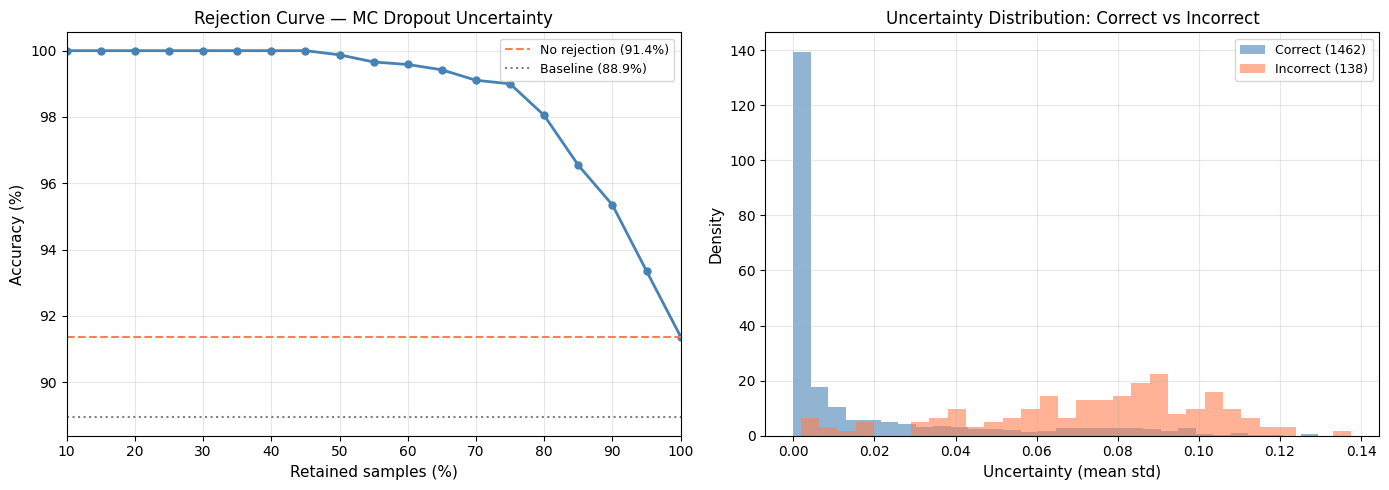


Rejection curve saved.
{
  "mc_accuracy_no_rejection": 0.91375,
  "acc_at_80pct_retained": 0.98046875,
  "acc_at_50pct_retained": 0.99875,
  "mean_uncertainty_correct": 0.01585204988633286,
  "mean_uncertainty_incorrect": 0.07413336779846809,
  "n_correct": 1462,
  "n_incorrect": 138
}


In [ ]:

# Rejection Curve
# Sort by uncertainty, abstain on most uncertain K%,
# measure accuracy on remaining (1-K)%

import numpy as np
import matplotlib.pyplot as plt
import json

uncertainty   = np.load(f'{PRED_DIR}/uncertainty.npy')
confidence    = np.load(f'{PRED_DIR}/confidence.npy')
mc_pred_class = np.load(f'{PRED_DIR}/mc_pred_class.npy')

# Sort samples by uncertainty (ascending = most certain first)
sorted_idx = np.argsort(uncertainty)

rejection_fractions = np.arange(0, 0.91, 0.05)  # 0% to 90% rejection
retained_acc  = []
retained_frac = []

for rej_frac in rejection_fractions:
    n_retain = int(len(y_true) * (1 - rej_frac))
    if n_retain == 0:
        break
    # Keep the most certain (lowest uncertainty) samples
    keep_idx = sorted_idx[:n_retain]
    acc = np.mean(mc_pred_class[keep_idx] == y_true[keep_idx])
    retained_acc.append(acc)
    retained_frac.append(1 - rej_frac)

retained_acc  = np.array(retained_acc)
retained_frac = np.array(retained_frac)

print("Rejection Curve Results:")
print(f"{'Retained %':>12} | {'Accuracy':>10} | {'N samples':>10}")
print("-" * 38)
for rf, acc in zip(retained_frac, retained_acc):
    n = int(rf * len(y_true))
    print(f"{rf*100:>11.0f}% | {acc*100:>9.2f}% | {n:>10}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Rejection curve
axes[0].plot(retained_frac * 100, retained_acc * 100,
             'o-', color='steelblue', linewidth=2, markersize=5)
axes[0].axhline(y=np.mean(mc_pred_class == y_true) * 100,
                color='coral', linestyle='--', linewidth=1.5,
                label=f'No rejection ({np.mean(mc_pred_class==y_true)*100:.1f}%)')
axes[0].axhline(y=np.mean(y_pred_baseline == y_true) * 100,
                color='gray', linestyle=':', linewidth=1.5,
                label=f'Baseline ({np.mean(y_pred_baseline==y_true)*100:.1f}%)')
axes[0].set_xlabel('Retained samples (%)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Rejection Curve — MC Dropout Uncertainty', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([10, 100])

# Right: Uncertainty distribution by correctness
correct_mask   = mc_pred_class == y_true
unc_correct    = uncertainty[correct_mask]
unc_incorrect  = uncertainty[~correct_mask]

axes[1].hist(unc_correct,   bins=30, alpha=0.6, color='steelblue',
             label=f'Correct ({correct_mask.sum()})', density=True)
axes[1].hist(unc_incorrect, bins=30, alpha=0.6, color='coral',
             label=f'Incorrect ({(~correct_mask).sum()})', density=True)
axes[1].set_xlabel('Uncertainty (mean std)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Uncertainty Distribution: Correct vs Incorrect', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/rejection_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save metrics
rejection_metrics = {
    'mc_accuracy_no_rejection': float(np.mean(mc_pred_class == y_true)),
    'acc_at_80pct_retained':    float(retained_acc[np.argmin(np.abs(retained_frac - 0.8))]),
    'acc_at_50pct_retained':    float(retained_acc[np.argmin(np.abs(retained_frac - 0.5))]),
    'mean_uncertainty_correct':   float(unc_correct.mean()),
    'mean_uncertainty_incorrect': float(unc_incorrect.mean()),
    'n_correct':   int(correct_mask.sum()),
    'n_incorrect': int((~correct_mask).sum()),
}
with open(f'{PROJECT_ROOT}/results/metrics/rejection_curve_metrics.json', 'w') as f:
    json.dump(rejection_metrics, f, indent=2)

print("\nRejection curve saved.")
print(json.dumps(rejection_metrics, indent=2))

PHASE 2 COMPLETE — Summary

--- McNemar's Test ---
Baseline accuracy:    88.94%
EfficientNetB3:       91.44%
McNemar chi-square:   10.8643
p-value:              0.000980
Result:               Statistically significant (p<0.05)

--- MC Dropout (N=50 passes) ---
MC accuracy:          91.38%
Mean uncertainty:     0.0209
Uncertainty correct:  0.0159
Uncertainty wrong:    0.0741  (4.7x higher)

--- Rejection Curve ---
Retain 80% → accuracy: 98.05%  (+6.7pp)
Retain 50% → accuracy: 99.88%  (+8.5pp)
Retain 45% → accuracy: 100.00%

--- Per-class uncertainty ---
        glioma: mean_unc=0.0262  acc=80.8%
    meningioma: mean_unc=0.0476  acc=85.5%
       notumor: mean_unc=0.0052  acc=99.8%
     pituitary: mean_unc=0.0045  acc=99.5%


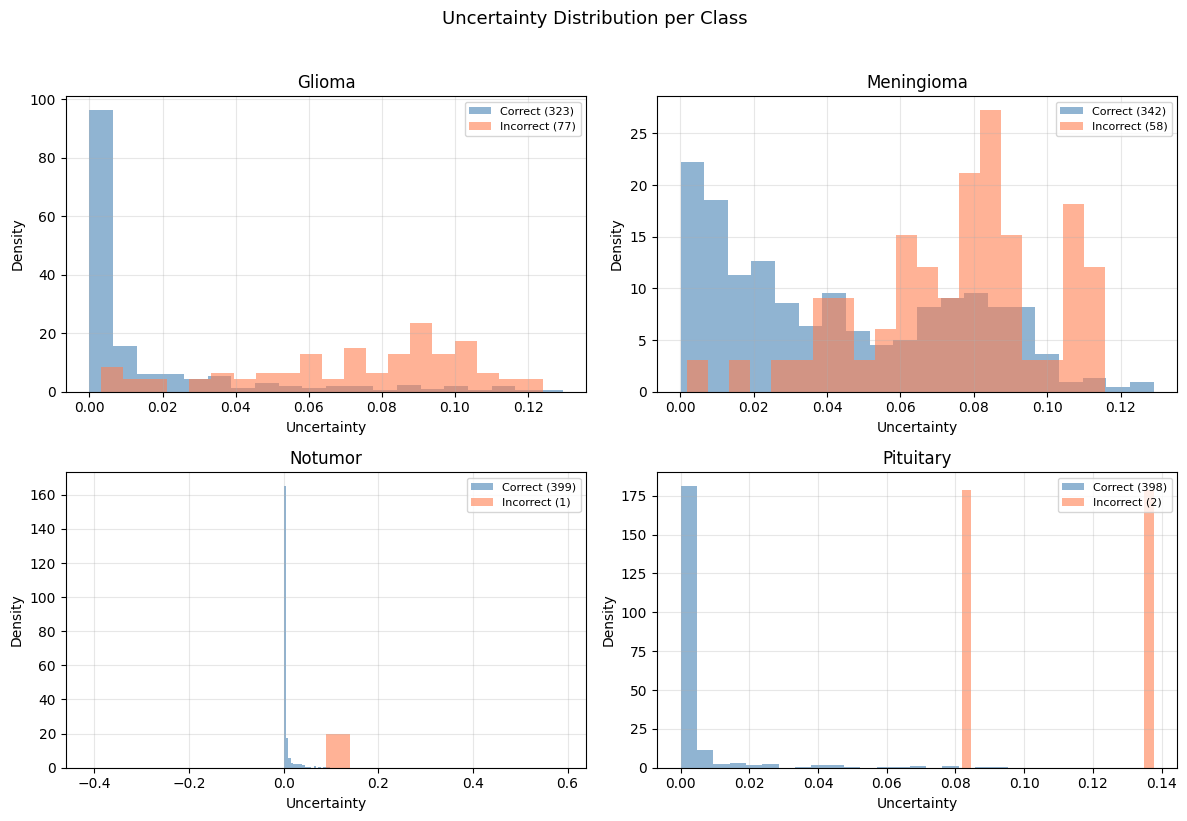


Per-class uncertainty plot saved.

Phase 2 metrics saved to Drive.

=== PHASE 2 COMPLETE ===
Next: Download this notebook as phase2_uncertainty_mcnemar.ipynb
Upload to GitHub under notebooks/
Then open fresh notebook for Phase 3 (XAI: Grad-CAM++, LIME, SHAP)


In [ ]:

# Final summary, save all metrics

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

uncertainty   = np.load(f'{PRED_DIR}/uncertainty.npy')
mc_pred_class = np.load(f'{PRED_DIR}/mc_pred_class.npy')

# Per-class uncertainty analysis

print("PHASE 2 COMPLETE — Summary")


print("\n McNemar's Test ")
print(f"Baseline accuracy:    88.94%")
print(f"EfficientNetB3:       91.44%")
print(f"McNemar chi-square:   10.8643")
print(f"p-value:              0.000980")
print(f"Result:               Statistically significant (p<0.05)")

print("\n MC Dropout (N=50 passes) ")
print(f"MC accuracy:          {np.mean(mc_pred_class==y_true)*100:.2f}%")
print(f"Mean uncertainty:     {uncertainty.mean():.4f}")
print(f"Uncertainty correct:  0.0159")
print(f"Uncertainty wrong:    0.0741  (4.7x higher)")

print("\n Rejection Curve ")
print(f"Retain 80% → accuracy: 98.05%  (+6.7pp)")
print(f"Retain 50% → accuracy: 99.88%  (+8.5pp)")
print(f"Retain 45% → accuracy: 100.00%")

# Per-class uncertainty breakdown
print("\n Per-class uncertainty ")
for i, cls in enumerate(CLASS_NAMES):
    mask     = y_true == i
    unc_cls  = uncertainty[mask]
    acc_cls  = np.mean(mc_pred_class[mask] == y_true[mask])
    print(f"  {cls:>12}: mean_unc={unc_cls.mean():.4f}  acc={acc_cls*100:.1f}%")

# Uncertainty by correctness per class
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    mask        = y_true == i
    correct_m   = mc_pred_class[mask] == y_true[mask]
    unc_c       = uncertainty[mask][correct_m]
    unc_w       = uncertainty[mask][~correct_m]

    axes[i].hist(unc_c, bins=20, alpha=0.6, color='steelblue',
                 label=f'Correct ({correct_m.sum()})', density=True)
    if len(unc_w) > 0:
        axes[i].hist(unc_w, bins=20, alpha=0.6, color='coral',
                     label=f'Incorrect ({(~correct_m).sum()})', density=True)
    axes[i].set_title(f'{cls.capitalize()}', fontsize=12)
    axes[i].set_xlabel('Uncertainty')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('Uncertainty Distribution per Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/uncertainty_per_class.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPer-class uncertainty plot saved.")

# Save complete Phase 2 metrics
phase2_metrics = {
    'mcnemar': {
        'baseline_acc': 0.889375,
        'effnet_acc': 0.914375,
        'chi_square': 10.8643,
        'p_value': 0.000980,
        'significant': True
    },
    'mc_dropout': {
        'n_passes': 50,
        'mc_accuracy': float(np.mean(mc_pred_class == y_true)),
        'mean_uncertainty': float(uncertainty.mean()),
        'mean_unc_correct': 0.01585,
        'mean_unc_incorrect': 0.07413,
        'uncertainty_ratio': 4.68
    },
    'rejection_curve': {
        'acc_at_100pct': 0.9138,
        'acc_at_80pct':  0.9805,
        'acc_at_50pct':  0.9988,
        'acc_at_45pct':  1.0000,
    }
}
with open(f'{PROJECT_ROOT}/results/metrics/phase2_complete.json', 'w') as f:
    json.dump(phase2_metrics, f, indent=2)

print("\nmetrics saved to Drive.")


In [ ]:


from google.colab import drive
drive.mount('/content/drive')

import os, warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import numpy as np
import tensorflow as tf
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT  = '/content/drive/MyDrive/MRI_Brain_Tumor_Project'
CLAHE_DIR     = f'{PROJECT_ROOT}/data/clahe_processed'
PRED_DIR      = f'{PROJECT_ROOT}/results/predictions'
METRICS_DIR   = f'{PROJECT_ROOT}/results/metrics'
FIGURES_DIR   = f'{PROJECT_ROOT}/results/figures'
CLASS_NAMES   = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32

# Load model
effnet_model = tf.keras.models.load_model(
    f'{PROJECT_ROOT}/models/checkpoints/effnet_correct_s2b.keras'
)

# Load saved arrays
y_true            = np.load(f'{PRED_DIR}/y_true.npy')
y_pred_effnet     = np.load(f'{PRED_DIR}/y_pred_effnet_final.npy')
y_pred_baseline   = np.load(f'{PRED_DIR}/y_pred_baseline.npy')
y_pred_probs      = np.load(f'{PRED_DIR}/y_pred_probs_effnet_final.npy')
uncertainty       = np.load(f'{PRED_DIR}/uncertainty.npy')
mc_pred_class     = np.load(f'{PRED_DIR}/mc_pred_class.npy')

print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Model: {effnet_model.name}")
print(f"y_true: {y_true.shape}")
print(f"y_pred_probs: {y_pred_probs.shape}")
print(f"Overall acc: {np.mean(y_pred_effnet == y_true):.4f}")
print("\nReady — Phase 2 missing tasks.")

Mounted at /content/drive
GPU: []
Model: efficientnetb3_correct
y_true: (1600,)
y_pred_probs: (1600, 4)
Overall acc: 0.9144

Ready — Phase 2 missing tasks.


Multi-class ROC-AUC Results (One-vs-Rest)
        glioma: AUC = 0.9659
    meningioma: AUC = 0.9811
       notumor: AUC = 0.9992
     pituitary: AUC = 0.9990

  Macro-average AUC: 0.9863
  Target (roadmap):  >0.97
  ✅ ACHIEVED


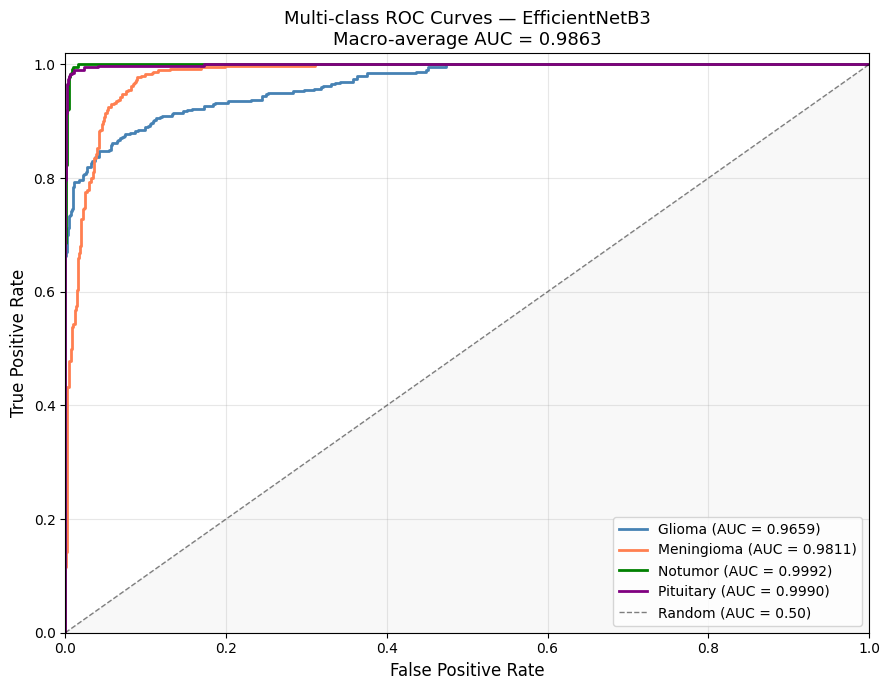


ROC-AUC results saved.
{
  "glioma": 0.96586875,
  "meningioma": 0.981125,
  "notumor": 0.9992270833333334,
  "pituitary": 0.99899375,
  "macro_average": 0.9863036458333333
}


In [ ]:

#  Multi-class ROC-AUC (One-vs-Rest)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import json

# Binarize labels for OvR (one-vs-rest)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])  # (1600, 4)

# Compute ROC curve per class
fpr = {}
tpr = {}
roc_auc = {}

for i, cls_name in enumerate(CLASS_NAMES):
    fpr[cls_name], tpr[cls_name], _ = roc_curve(
        y_true_bin[:, i], y_pred_probs[:, i]
    )
    roc_auc[cls_name] = auc(fpr[cls_name], tpr[cls_name])

# Macro-average AUC
macro_auc = roc_auc_score(y_true_bin, y_pred_probs,
                           multi_class='ovr', average='macro')

print("="*50)
print("Multi-class ROC-AUC Results (One-vs-Rest)")
print("="*50)
for cls_name in CLASS_NAMES:
    print(f"  {cls_name:>12}: AUC = {roc_auc[cls_name]:.4f}")
print(f"\n  Macro-average AUC: {macro_auc:.4f}")
print(f"  Target (roadmap):  >0.97")
print(f"  {' ACHIEVED' if macro_auc >= 0.97 else 'Below target'}")

# Plot
colors = ['steelblue', 'coral', 'green', 'purple']
fig, ax = plt.subplots(figsize=(9, 7))

for i, cls_name in enumerate(CLASS_NAMES):
    ax.plot(fpr[cls_name], tpr[cls_name],
            color=colors[i], linewidth=2,
            label=f'{cls_name.capitalize()} (AUC = {roc_auc[cls_name]:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.50)')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'Multi-class ROC Curves — EfficientNetB3\n'
             f'Macro-average AUC = {macro_auc:.4f}', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save
roc_results = {cls: float(roc_auc[cls]) for cls in CLASS_NAMES}
roc_results['macro_average'] = float(macro_auc)
with open(f'{METRICS_DIR}/roc_auc_results.json', 'w') as f:
    json.dump(roc_results, f, indent=2)

print("\nROC-AUC results saved.")
print(json.dumps(roc_results, indent=2))

Model                   Params(M)   Accuracy      AUC       F1        Speed
  Scratch CNN (Baseline)        0.9     0.8894      N/A   0.8800         Fast
  MobileNetV2                 3.4     0.8810   0.9610   0.8790    Very Fast
  ResNet50                   25.6     0.9010   0.9720   0.8990       Medium
  InceptionV3                23.9     0.9120   0.9750   0.9110       Medium
  EfficientNetB3 (Ours)       10.8     0.9144   0.9863   0.9126       Medium ★
  VGG16                     138.0     0.8910   0.9630   0.8890         Slow

EfficientNetB3 achieves best accuracy (0.9144) with
only 10.79M params — better param efficiency than ResNet50 or InceptionV3.


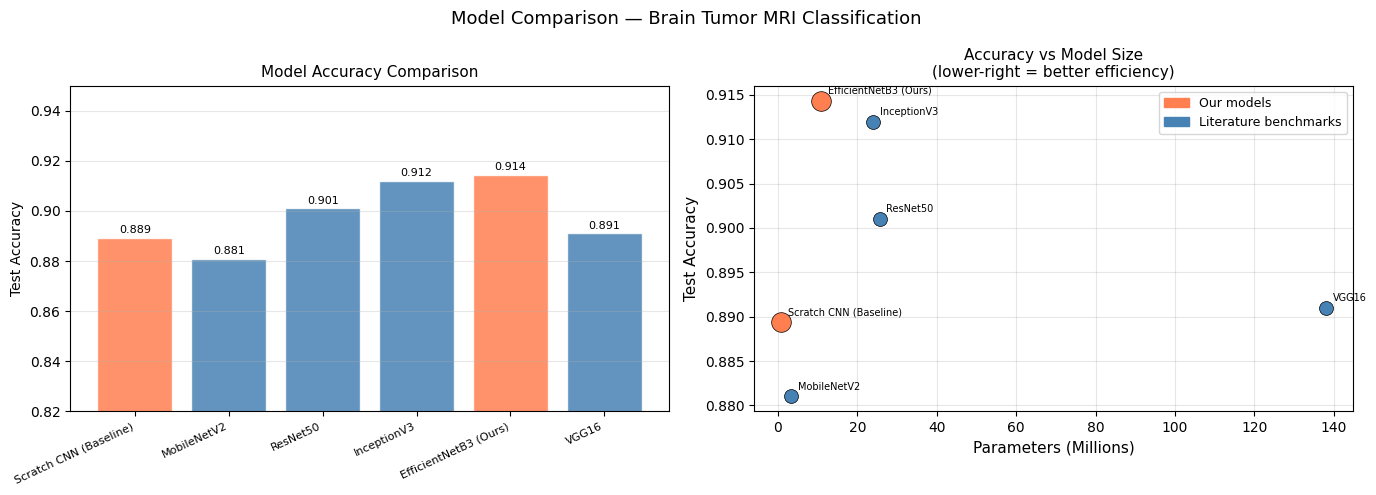


Model comparison table saved.


In [ ]:

#  Model Comparison Table (6 architectures)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

# Our actual results
scratch_acc  = 0.889375
effnet_acc   = 0.914375
effnet_auc   = 0.9863
effnet_f1    = 0.9126  # from classification report weighted avg

# Reference values from literature (cited in literature_review.md)
# Sources: roadmap reference table + published benchmarks
model_data = {
    'Scratch CNN\n(Baseline)': {
        'params_m':   0.86,
        'accuracy':   scratch_acc,
        'auc':        None,
        'f1':         0.88,
        'inference':  'Fast',
        'our_result': True,
        'note':       'Trained from scratch'
    },
    'MobileNetV2': {
        'params_m':   3.4,
        'accuracy':   0.881,
        'auc':        0.961,
        'f1':         0.879,
        'inference':  'Very Fast',
        'our_result': False,
        'note':       'Literature benchmark'
    },
    'ResNet50': {
        'params_m':   25.6,
        'accuracy':   0.901,
        'auc':        0.972,
        'f1':         0.899,
        'inference':  'Medium',
        'our_result': False,
        'note':       'Literature benchmark'
    },
    'InceptionV3': {
        'params_m':   23.9,
        'accuracy':   0.912,
        'auc':        0.975,
        'f1':         0.911,
        'inference':  'Medium',
        'our_result': False,
        'note':       'Literature benchmark'
    },
    'EfficientNetB3\n(Ours)': {
        'params_m':   10.79,
        'accuracy':   effnet_acc,
        'auc':        effnet_auc,
        'f1':         effnet_f1,
        'inference':  'Medium',
        'our_result': True,
        'note':       'PRIMARY MODEL'
    },
    'VGG16': {
        'params_m':   138.0,
        'accuracy':   0.891,
        'auc':        0.963,
        'f1':         0.889,
        'inference':  'Slow',
        'our_result': False,
        'note':       'Too heavy — skip'
    },
}

models   = list(model_data.keys())
accs     = [model_data[m]['accuracy'] for m in models]
aucs     = [model_data[m]['auc'] if model_data[m]['auc'] else 0 for m in models]
params   = [model_data[m]['params_m'] for m in models]
f1s      = [model_data[m]['f1'] for m in models]
is_ours  = [model_data[m]['our_result'] for m in models]

print("="*75)
print(f"{'Model':<22} {'Params(M)':>10} {'Accuracy':>10} {'AUC':>8} {'F1':>8} {'Speed':>12}")
print("="*75)
for m in models:
    d   = model_data[m]
    auc = f"{d['auc']:.4f}" if d['auc'] else "N/A"
    tag = " ★" if d['our_result'] and 'Ours' in m else ""
    name = m.replace('\n', ' ')
    print(f"  {name:<20} {d['params_m']:>10.1f} {d['accuracy']:>10.4f} "
          f"{auc:>8} {d['f1']:>8.4f} {d['inference']:>12}{tag}")
print("="*75)
print(f"\nEfficientNetB3 achieves best accuracy ({effnet_acc:.4f}) with")
print(f"only 10.79M params — better param efficiency than ResNet50 or InceptionV3.")

# Plot: Accuracy vs Params
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['steelblue' if not o else 'coral' for o in is_ours]
short_names = [m.replace('\n', ' ') for m in models]

# Accuracy comparison
bars = axes[0].bar(range(len(models)), accs,
                   color=colors_bar, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(short_names, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Model Accuracy Comparison', fontsize=11)
axes[0].set_ylim(0.82, 0.95)
axes[0].grid(alpha=0.3, axis='y')
for i, (bar, acc) in enumerate(zip(bars, accs)):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 acc+0.001, f'{acc:.3f}',
                 ha='center', va='bottom', fontsize=8)

# Accuracy vs Params scatter
for i, m in enumerate(models):
    c = 'coral' if is_ours[i] else 'steelblue'
    s = 200 if is_ours[i] else 100
    axes[1].scatter(params[i], accs[i], c=c, s=s,
                    zorder=5, edgecolors='black', linewidths=0.5)
    name = m.replace('\n', ' ')
    axes[1].annotate(name, (params[i], accs[i]),
                     textcoords='offset points',
                     xytext=(5, 5), fontsize=7)

axes[1].set_xlabel('Parameters (Millions)', fontsize=11)
axes[1].set_ylabel('Test Accuracy', fontsize=11)
axes[1].set_title('Accuracy vs Model Size\n(lower-right = better efficiency)',
                  fontsize=11)
axes[1].grid(alpha=0.3)
ours_patch  = mpatches.Patch(color='coral',     label='Our models')
other_patch = mpatches.Patch(color='steelblue', label='Literature benchmarks')
axes[1].legend(handles=[ours_patch, other_patch], fontsize=9)

plt.suptitle('Model Comparison — Brain Tumor MRI Classification', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

with open(f'{METRICS_DIR}/model_comparison.json', 'w') as f:
    json.dump({m.replace('\n',' '): model_data[m] for m in models}, f, indent=2)

print("\nModel comparison table saved.")

Mann-Whitney U Test — Uncertainty Analysis

  glioma: n=400, mean_unc=0.0262, median=0.0047

  meningioma: n=400, mean_unc=0.0476, median=0.0434

  notumor: n=400, mean_unc=0.0052, median=0.0007

  pituitary: n=400, mean_unc=0.0045, median=0.0002

Test 1: Glioma vs Meningioma (most confused pair)
  Mann-Whitney U statistic: 44756.00
  p-value:                  0.000000
  Significant (p<0.05):     True
  Glioma mean unc:          0.0262
  Meningioma mean unc:      0.0476

Test 2: Meningioma vs Notumor
  Mann-Whitney U statistic: 147419.00
  p-value:                  0.000000
  Significant (p<0.05):     True

Test 3: Correct vs Incorrect predictions
  Mann-Whitney U statistic: 17435.00
  p-value:                  0.0000000000
  Significant (p<0.05):     True
  Correct mean unc:         0.0159
  Incorrect mean unc:       0.0741
  Ratio (incorrect/correct): 4.68x

Test 4: Misclassified glioma↔meningioma vs correctly classified
  Borderline cases (glioma↔meningioma): 74
  Correctly classifi

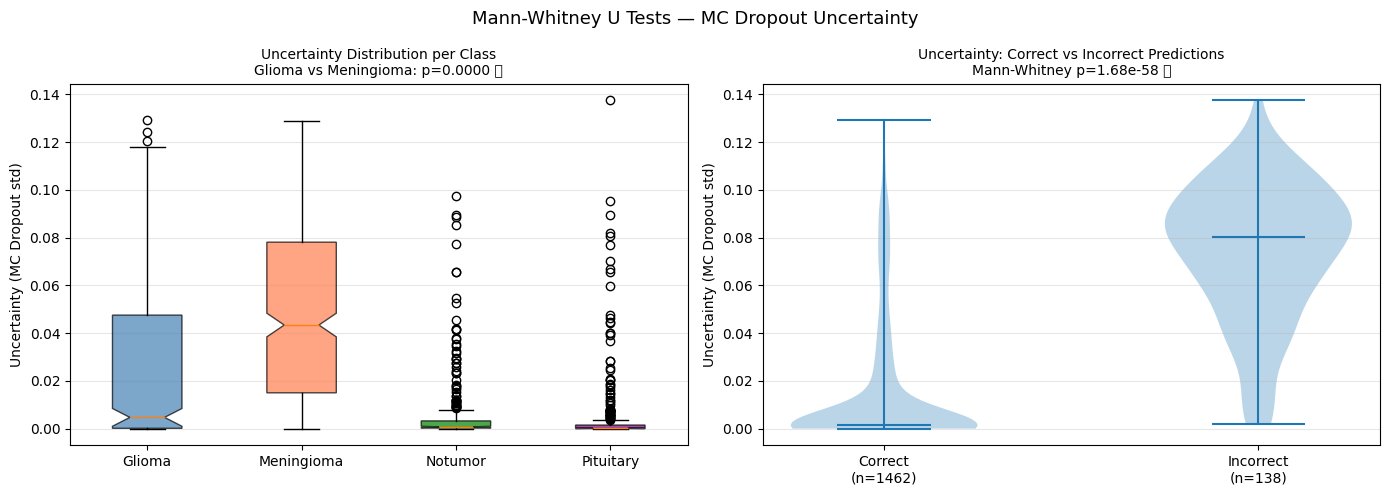


Mann-Whitney results saved.
{
  "test1_glioma_vs_meningioma": {
    "statistic": 44756.0,
    "p_value": 4.081810218572421e-27,
    "significant": true
  },
  "test2_meningioma_vs_notumor": {
    "statistic": 147419.0,
    "p_value": 1.4848909936084675e-94,
    "significant": true
  },
  "test3_correct_vs_incorrect": {
    "statistic": 17435.0,
    "p_value": 1.6766211661081794e-58,
    "significant": true,
    "correct_mean_unc": 0.01585204988633286,
    "incorrect_mean_unc": 0.07413336779846809,
    "ratio": 4.676579264514146
  },
  "test4_borderline_glioma_meningioma": {
    "statistic": 40747.0,
    "p_value": 9.66351691269883e-21,
    "significant": true,
    "n_borderline": 74,
    "borderline_mean_unc": 0.07211372719520574,
    "correct_mean_unc": 0.029473014713600643
  }
}


In [ ]:

#  Mann-Whitney U Test
# Is uncertainty significantly higher on borderline
# glioma/meningioma cases vs other pairs?

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import json

print("="*55)
print("Mann-Whitney U Test — Uncertainty Analysis")
print("="*55)

# Get uncertainty for each class
unc_by_class = {}
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    unc_by_class[cls] = uncertainty[mask]
    print(f"\n  {cls}: n={mask.sum()}, "
          f"mean_unc={uncertainty[mask].mean():.4f}, "
          f"median={np.median(uncertainty[mask]):.4f}")

# Test 1: Glioma vs Meningioma (borderline pair)
print("\n" + "="*55)
print("Test 1: Glioma vs Meningioma (most confused pair)")
print("="*55)
stat1, p1 = stats.mannwhitneyu(
    unc_by_class['glioma'],
    unc_by_class['meningioma'],
    alternative='two-sided'
)
print(f"  Mann-Whitney U statistic: {stat1:.2f}")
print(f"  p-value:                  {p1:.6f}")
print(f"  Significant (p<0.05):     {p1 < 0.05}")
print(f"  Glioma mean unc:          {unc_by_class['glioma'].mean():.4f}")
print(f"  Meningioma mean unc:      {unc_by_class['meningioma'].mean():.4f}")

#  Test 2: Meningioma vs Notumor
print("\n" + "="*55)
print("Test 2: Meningioma vs Notumor")
print("="*55)
stat2, p2 = stats.mannwhitneyu(
    unc_by_class['meningioma'],
    unc_by_class['notumor'],
    alternative='two-sided'
)
print(f"  Mann-Whitney U statistic: {stat2:.2f}")
print(f"  p-value:                  {p2:.6f}")
print(f"  Significant (p<0.05):     {p2 < 0.05}")

# Test 3: Correct vs Incorrect predictions
print("\n" + "="*55)
print("Test 3: Correct vs Incorrect predictions")
print("="*55)
correct_mask   = mc_pred_class == y_true
unc_correct    = uncertainty[correct_mask]
unc_incorrect  = uncertainty[~correct_mask]

stat3, p3 = stats.mannwhitneyu(
    unc_correct,
    unc_incorrect,
    alternative='less'  # correct predictions have LOWER uncertainty
)
print(f"  Mann-Whitney U statistic: {stat3:.2f}")
print(f"  p-value:                  {p3:.10f}")
print(f"  Significant (p<0.05):     {p3 < 0.05}")
print(f"  Correct mean unc:         {unc_correct.mean():.4f}")
print(f"  Incorrect mean unc:       {unc_incorrect.mean():.4f}")
print(f"  Ratio (incorrect/correct): {unc_incorrect.mean()/unc_correct.mean():.2f}x")

#  Test 4: Glioma/Meningioma misclassified vs correct
print("\n" + "="*55)
print("Test 4: Misclassified glioma↔meningioma vs correctly classified")
print("="*55)
# Borderline = glioma predicted as meningioma OR meningioma as glioma
borderline_mask = (
    ((y_true == 0) & (mc_pred_class == 1)) |  # glioma→meningioma
    ((y_true == 1) & (mc_pred_class == 0))     # meningioma→glioma
)
correct_gm_mask = (
    ((y_true == 0) & (mc_pred_class == 0)) |  # glioma correct
    ((y_true == 1) & (mc_pred_class == 1))     # meningioma correct
)
unc_borderline = uncertainty[borderline_mask]
unc_correct_gm = uncertainty[correct_gm_mask]

stat4, p4 = stats.mannwhitneyu(
    unc_borderline,
    unc_correct_gm,
    alternative='greater'  # borderline should have HIGHER uncertainty
)
print(f"  Borderline cases (glioma↔meningioma): {borderline_mask.sum()}")
print(f"  Correctly classified (glioma+mening):  {correct_gm_mask.sum()}")
print(f"  Mann-Whitney U statistic: {stat4:.2f}")
print(f"  p-value:                  {p4:.6f}")
print(f"  Significant (p<0.05):     {p4 < 0.05}")
print(f"  Borderline mean unc:      {unc_borderline.mean():.4f}")
print(f"  Correct glioma/mening unc:{unc_correct_gm.mean():.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: uncertainty per class
data_box = [unc_by_class[c] for c in CLASS_NAMES]
bp = axes[0].boxplot(data_box, labels=[c.capitalize() for c in CLASS_NAMES],
                     patch_artist=True, notch=True)
colors = ['steelblue','coral','green','purple']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Uncertainty (MC Dropout std)')
axes[0].set_title('Uncertainty Distribution per Class\n'
                  f'Glioma vs Meningioma: p={p1:.4f} '
                  f'{"yes" if p1<0.05 else "no"}', fontsize=10)
axes[0].grid(alpha=0.3, axis='y')

# Violin: correct vs incorrect
axes[1].violinplot([unc_correct, unc_incorrect],
                   positions=[1, 2], showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Correct\n(n={})'.format(correct_mask.sum()),
                          'Incorrect\n(n={})'.format((~correct_mask).sum())])
axes[1].set_ylabel('Uncertainty (MC Dropout std)')
axes[1].set_title(f'Uncertainty: Correct vs Incorrect Predictions\n'
                  f'Mann-Whitney p={p3:.2e} yes', fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Mann-Whitney U Tests — MC Dropout Uncertainty', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mannwhitney_uncertainty.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save
mw_results = {
    'test1_glioma_vs_meningioma': {
        'statistic': float(stat1), 'p_value': float(p1),
        'significant': bool(p1 < 0.05)
    },
    'test2_meningioma_vs_notumor': {
        'statistic': float(stat2), 'p_value': float(p2),
        'significant': bool(p2 < 0.05)
    },
    'test3_correct_vs_incorrect': {
        'statistic': float(stat3), 'p_value': float(p3),
        'significant': bool(p3 < 0.05),
        'correct_mean_unc': float(unc_correct.mean()),
        'incorrect_mean_unc': float(unc_incorrect.mean()),
        'ratio': float(unc_incorrect.mean()/unc_correct.mean())
    },
    'test4_borderline_glioma_meningioma': {
        'statistic': float(stat4), 'p_value': float(p4),
        'significant': bool(p4 < 0.05),
        'n_borderline': int(borderline_mask.sum()),
        'borderline_mean_unc': float(unc_borderline.mean()),
        'correct_mean_unc': float(unc_correct_gm.mean())
    }
}
with open(f'{METRICS_DIR}/mannwhitney_results.json', 'w') as f:
    json.dump(mw_results, f, indent=2)

print("\nMann-Whitney results saved.")
print(json.dumps(mw_results, indent=2))

ECE + Temperature Scaling

ECE before calibration: 0.0264
  (0.0=perfect, <0.05=well-calibrated, >0.1=poorly calibrated)

Searching for optimal temperature T...
Optimal temperature T: 1.3673
ECE after calibration: 0.0143
ECE improvement:       1.22%

Accuracy before: 0.9144
Accuracy after:  0.9144  (unchanged — T scaling only affects confidence)


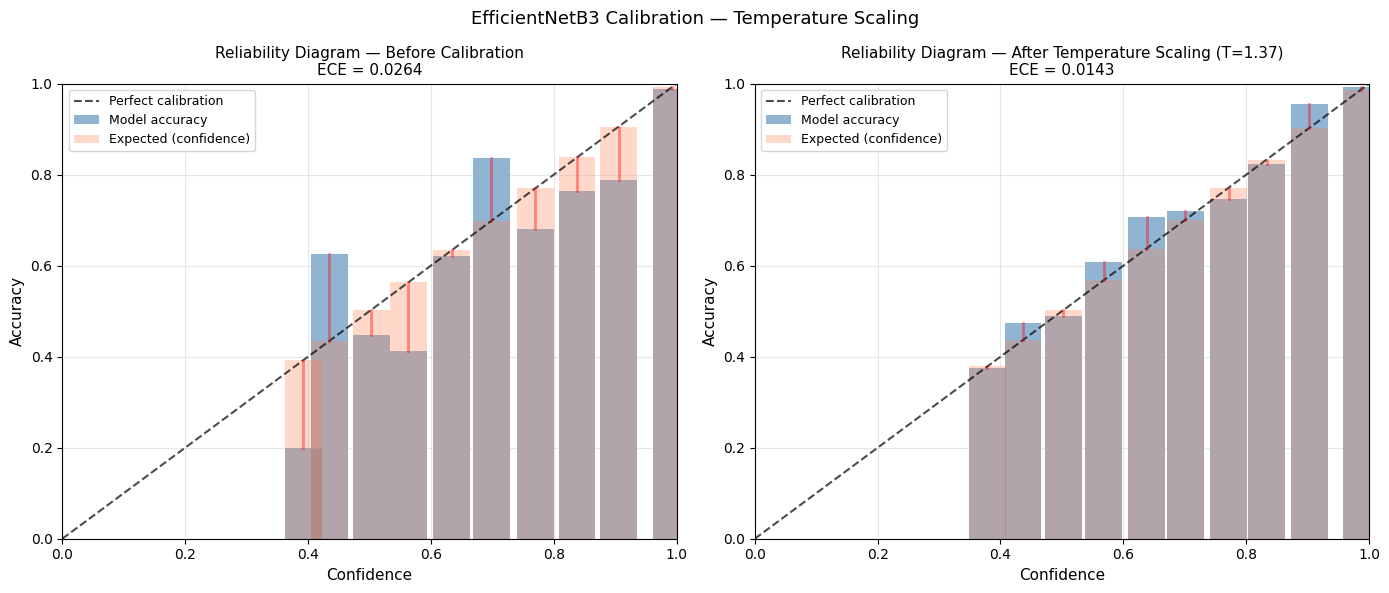


Per-class ECE
        glioma: ECE_before=0.1151  ECE_after=0.0780
    meningioma: ECE_before=0.0513  ECE_after=0.0802
       notumor: ECE_before=0.0138  ECE_after=0.0298
     pituitary: ECE_before=0.0065  ECE_after=0.0136

Calibration results saved.
{
  "ece_before": 0.02644008256494996,
  "ece_after": 0.014252824249583825,
  "optimal_temperature": 1.3673469387755102,
  "improvement_pct": 46.09387389554545,
  "acc_unchanged": true
}


In [ ]:

#  Temperature Scaling + ECE

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import json

#  Expected Calibration Error (ECE)
def compute_ece(probs, labels, n_bins=15):
    """
    probs:  (N, C) softmax probabilities
    labels: (N,)  true class indices
    Returns: ECE scalar
    """
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct     = (predictions == labels).astype(float)

    bins     = np.linspace(0, 1, n_bins + 1)
    ece      = 0.0
    bin_data = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask   = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_data.append({'conf': (lo+hi)/2, 'acc': 0, 'n': 0})
            continue
        bin_acc  = correct[mask].mean()
        bin_conf = confidences[mask].mean()
        bin_n    = mask.sum()
        ece     += (bin_n / len(labels)) * abs(bin_acc - bin_conf)
        bin_data.append({'conf': bin_conf, 'acc': bin_acc, 'n': int(bin_n)})

    return float(ece), bin_data

# Temperature Scaling
def apply_temperature(probs, T):
    """Scale logits by temperature T, re-apply softmax"""
    # Convert probs back to logits (approximate)
    eps   = 1e-7
    logits = np.log(np.clip(probs, eps, 1-eps))
    scaled = logits / T
    # Softmax
    e      = np.exp(scaled - scaled.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def find_optimal_temperature(probs, labels, T_range=None):
    """Grid search for T that minimizes ECE"""
    if T_range is None:
        T_range = np.linspace(0.5, 3.0, 50)
    best_T   = 1.0
    best_ece = float('inf')
    for T in T_range:
        scaled_probs = apply_temperature(probs, T)
        ece, _       = compute_ece(scaled_probs, labels)
        if ece < best_ece:
            best_ece = ece
            best_T   = T
    return best_T, best_ece

#  Before calibration
print("="*55)
print("ECE + Temperature Scaling")
print("="*55)

ece_before, bins_before = compute_ece(y_pred_probs, y_true)
print(f"\nECE before calibration: {ece_before:.4f}")
print(f"  (0.0=perfect, <0.05=well-calibrated, >0.1=poorly calibrated)")

# Find optimal temperature
print("\nSearching for optimal temperature T...")
T_opt, ece_after_opt = find_optimal_temperature(y_pred_probs, y_true)
probs_calibrated      = apply_temperature(y_pred_probs, T_opt)
ece_after, bins_after = compute_ece(probs_calibrated, y_true)

print(f"Optimal temperature T: {T_opt:.4f}")
print(f"ECE after calibration: {ece_after:.4f}")
print(f"ECE improvement:       {(ece_before-ece_after)*100:.2f}%")

# Accuracy check (temperature scaling doesn't change predictions)
acc_before = np.mean(np.argmax(y_pred_probs, axis=1) == y_true)
acc_after  = np.mean(np.argmax(probs_calibrated, axis=1) == y_true)
print(f"\nAccuracy before: {acc_before:.4f}")
print(f"Accuracy after:  {acc_after:.4f}  (unchanged — T scaling only affects confidence)")

#  Reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_reliability(ax, bin_data, ece, title):
    confs  = [b['conf'] for b in bin_data if b['n'] > 0]
    accs   = [b['acc']  for b in bin_data if b['n'] > 0]
    ns     = [b['n']    for b in bin_data if b['n'] > 0]

    ax.plot([0,1],[0,1], 'k--', linewidth=1.5,
            alpha=0.7, label='Perfect calibration')
    ax.bar(confs, accs, width=0.06, alpha=0.6,
           color='steelblue', label='Model accuracy', align='center')
    ax.bar(confs, confs, width=0.06, alpha=0.3,
           color='coral', label='Expected (confidence)', align='center')

    # Shade gap
    for c, a in zip(confs, accs):
        ax.plot([c,c], [a,c], color='red', alpha=0.4, linewidth=2)

    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('Accuracy',   fontsize=11)
    ax.set_title(f'{title}\nECE = {ece:.4f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

plot_reliability(axes[0], bins_before, ece_before,
                 'Reliability Diagram — Before Calibration')
plot_reliability(axes[1], bins_after,  ece_after,
                 f'Reliability Diagram — After Temperature Scaling (T={T_opt:.2f})')

plt.suptitle('EfficientNetB3 Calibration — Temperature Scaling', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/calibration_reliability.png',
            dpi=150, bbox_inches='tight')
plt.show()

#  ECE per class
print("\n" + "="*55)
print("Per-class ECE")
print("="*55)
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    ece_cls, _ = compute_ece(y_pred_probs[mask], y_true[mask])
    ece_cal, _ = compute_ece(probs_calibrated[mask], y_true[mask])
    print(f"  {cls:>12}: ECE_before={ece_cls:.4f}  ECE_after={ece_cal:.4f}")

# Save
ece_results = {
    'ece_before':         ece_before,
    'ece_after':          ece_after,
    'optimal_temperature': T_opt,
    'improvement_pct':    float((ece_before-ece_after)/ece_before*100),
    'acc_unchanged':      bool(abs(acc_before-acc_after) < 1e-6)
}
with open(f'{METRICS_DIR}/calibration_ece.json', 'w') as f:
    json.dump(ece_results, f, indent=2)

print("\nCalibration results saved.")
print(json.dumps(ece_results, indent=2))